In [1]:
import os
import pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from pathlib import Path

In [2]:
# Directory comtaining merged, per-chromosome PLINK files
GENOTYPE_TRAIN_DIR = "/gpfs/commons/groups/knowles_lab/vmazeeva/BigBrain/Processed/Train/chroms"
GENOTYPE_TEST_DIR = "/gpfs/commons/groups/knowles_lab/vmazeeva/BigBrain/Processed/Test/chroms"

VARIANT_STATS_TRAIN = Path(GENOTYPE_TRAIN_DIR) / "variant_stats.csv"
VARIANT_STATS_TEST = Path(GENOTYPE_TEST_DIR) / "variant_stats.csv"

In [3]:
variant_stats_train = pd.read_csv(VARIANT_STATS_TRAIN)
variant_stats_test = pd.read_csv(VARIANT_STATS_TEST)

In [6]:
ANNOTATIONS_DIR_TRAIN = "/gpfs/commons/groups/knowles_lab/vmazeeva/BigBrain/Processed/Train/annotations"
ANNOTATIONS_DIR_TEST = "/gpfs/commons/groups/knowles_lab/vmazeeva/BigBrain/Processed/Test/annotations"

In [22]:
variant_mapping_stats_train = dict()
variant_mapping_stats_test = dict()

for chrom in range(1,23):
    # Train
    variants_stats_file_train = os.path.join(ANNOTATIONS_DIR_TRAIN, f"chr{chrom}", f"variant_gene_counts.txt")
    gene_stats_file_train = os.path.join(ANNOTATIONS_DIR_TRAIN, f"chr{chrom}", "gene_variant_counts.txt")
    variant_stats_df_train = pd.read_csv(variants_stats_file_train, sep="\t")
    gene_stats_df_train = pd.read_csv(gene_stats_file_train, sep="\t")
    total_variants_train = variant_stats_train.loc[variant_stats_train['chromosome'] == chrom, 'unique_positions'].values[0]
    mapped_variants_train = len(variant_stats_df_train)
    assert(mapped_variants_train == len(set(variant_stats_df_train['variant'].to_list()))) # mapping should drop duplicates
    
    # Test
    variants_stats_file_test = os.path.join(ANNOTATIONS_DIR_TEST, f"chr{chrom}", f"variant_gene_counts.txt")
    gene_stats_file_test = os.path.join(ANNOTATIONS_DIR_TEST, f"chr{chrom}", "gene_variant_counts.txt")
    variant_stats_df_test = pd.read_csv(variants_stats_file_test, sep="\t")
    gene_stats_df_test = pd.read_csv(gene_stats_file_test, sep="\t")
    total_variants_test = variant_stats_test.loc[variant_stats_test['chromosome'] == chrom, 'unique_positions'].values[0]
    mapped_variants_test = len(variant_stats_df_test)
    assert(mapped_variants_test == len(set(variant_stats_df_test['variant'].to_list()))) # mapping should drop duplicates
    
    variant_mapping_stats_train[f"Chrom {chrom}"] = {"total": int(total_variants_train), "mapped": mapped_variants_train}
    variant_mapping_stats_test[f"Chrom {chrom}"] = {"total": int(total_variants_test), "mapped": mapped_variants_test}

    

In [23]:
# Global sums - Train
total_variants_train  = sum(chrom['total'] for chrom in variant_mapping_stats_train.values())
mapped_variants_train = sum(chrom['mapped'] for chrom in variant_mapping_stats_train.values())

# Percentage mapped
percent_mapped_train = mapped_variants_train / total_variants_train * 100

# Print the result
print(f"TRAIN: Global Total Variants: {total_variants_train:,}")
print(f"TRAIN: Global Mapped Variants: {mapped_variants_train:,}")
print(f"TRAIN: Percent Mapped: {percent_mapped_train:.2f}%")

TRAIN: Global Total Variants: 80,748,306
TRAIN: Global Mapped Variants: 51,584,465
TRAIN: Percent Mapped: 63.88%


In [24]:
# Global sums - Test
total_variants_test  = sum(chrom['total'] for chrom in variant_mapping_stats_test.values())
mapped_variants_test = sum(chrom['mapped'] for chrom in variant_mapping_stats_test.values())

# Percentage mapped
percent_mapped_test = mapped_variants_test / total_variants_test * 100

# Print the result
print(f"TEST: Global Total Variants: {total_variants_test:,}")
print(f"TEST: Global Mapped Variants: {mapped_variants_test:,}")
print(f"TEST: Percent Mapped: {percent_mapped_test:.2f}%")

TEST: Global Total Variants: 45,546,574
TEST: Global Mapped Variants: 31,551,410
TEST: Percent Mapped: 69.27%


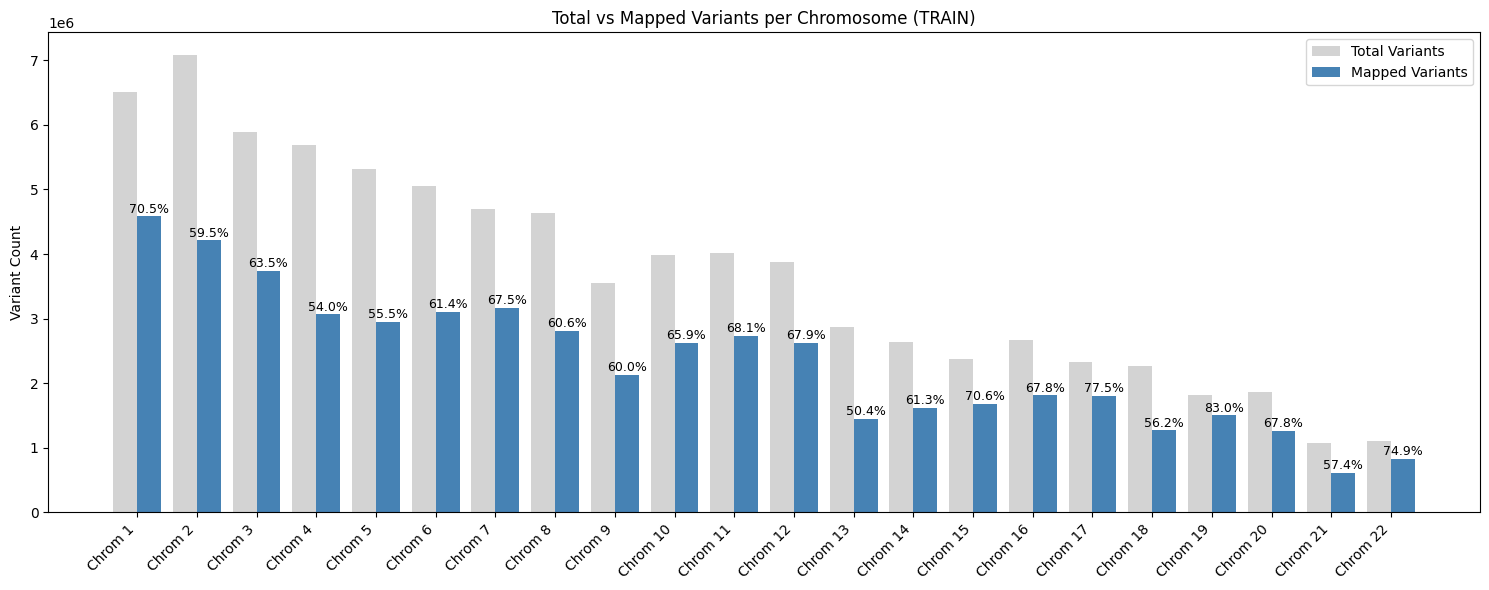

In [18]:
# Convert to DataFrame - Train
df_train = pd.DataFrame(variant_mapping_stats_train).T
df_train.index.name = 'Chromosome'
df_train.reset_index(inplace=True)

# Calculate mapped percentage
df_train['mapped_pct'] = (df_train['mapped'] / df_train['total']) * 100

# Plot
fig, ax = plt.subplots(figsize=(15, 6))

x = np.arange(len(df_train))
width = 0.4

# Bars
bars_total = ax.bar(x - width/2, df_train['total'], width, label='Total Variants', color='lightgray')
bars_mapped = ax.bar(x + width/2, df_train['mapped'], width, label='Mapped Variants', color='steelblue')

# Add percentage labels above mapped bars
for i, bar in enumerate(bars_mapped):
    pct = df_train['mapped_pct'].iloc[i]
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10000,
            f"{pct:.1f}%", ha='center', va='bottom', fontsize=9, color='black')

# X-axis labels
ax.set_xticks(x)
ax.set_xticklabels(df_train['Chromosome'], rotation=45, ha='right')

# Labels and title
ax.set_ylabel('Variant Count')
ax.set_title('Total vs Mapped Variants per Chromosome (TRAIN)')
ax.legend()

plt.tight_layout()
plt.show()

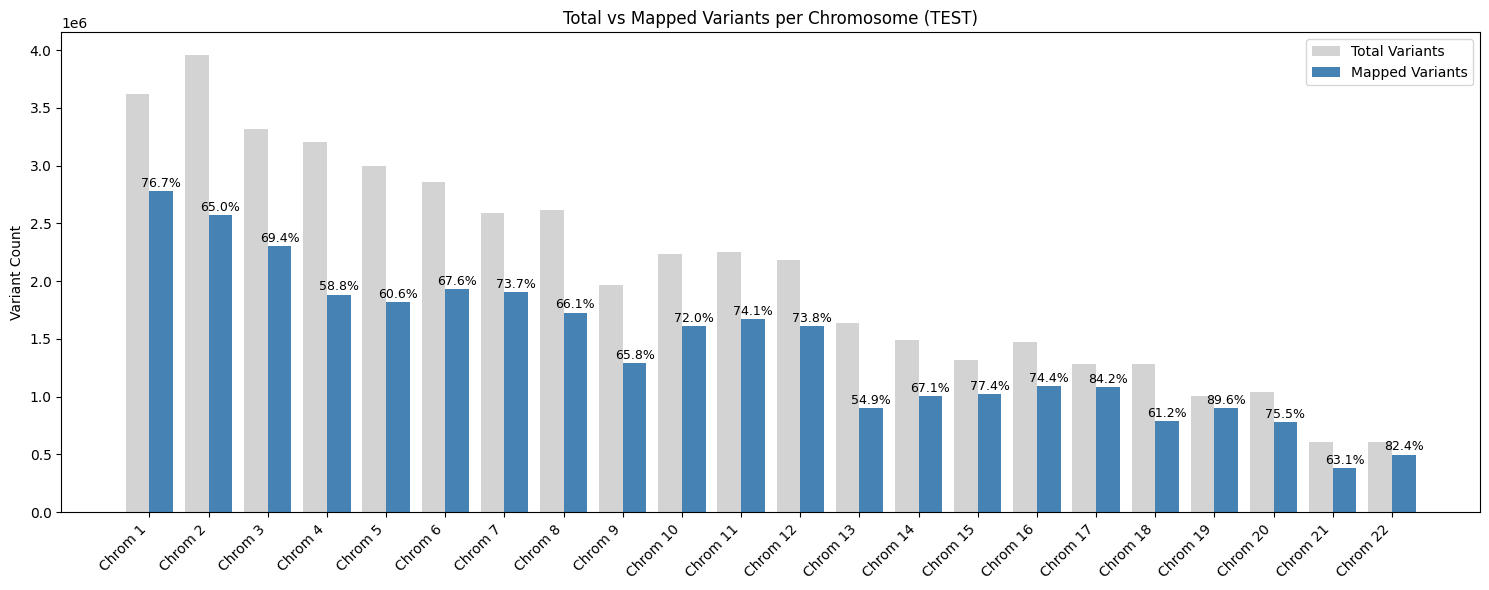

In [19]:
# Convert to DataFrame - Test
df_test = pd.DataFrame(variant_mapping_stats_test).T
df_test.index.name = 'Chromosome'
df_test.reset_index(inplace=True)

# Calculate mapped percentage
df_test['mapped_pct'] = (df_test['mapped'] / df_test['total']) * 100

# Plot
fig, ax = plt.subplots(figsize=(15, 6))

x = np.arange(len(df_test))
width = 0.4

# Bars
bars_total = ax.bar(x - width/2, df_test['total'], width, label='Total Variants', color='lightgray')
bars_mapped = ax.bar(x + width/2, df_test['mapped'], width, label='Mapped Variants', color='steelblue')

# Add percentage labels above mapped bars
for i, bar in enumerate(bars_mapped):
    pct = df_test['mapped_pct'].iloc[i]
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10000,
            f"{pct:.1f}%", ha='center', va='bottom', fontsize=9, color='black')

# X-axis labels
ax.set_xticks(x)
ax.set_xticklabels(df_test['Chromosome'], rotation=45, ha='right')

# Labels and title
ax.set_ylabel('Variant Count')
ax.set_title('Total vs Mapped Variants per Chromosome (TEST)')
ax.legend()

plt.tight_layout()
plt.show()

In [20]:
# Variant to number of genes mapping 

# Train
variants_num_genes_train = dict()
variants_num_genes_all_train = defaultdict(int)

# Test
variants_num_genes_test = dict()
variants_num_genes_all_test = defaultdict(int)

for chrom in range(1,23):
    # Train
    variants_num_genes_train[f"Chrom {chrom}"] = dict()
    variants_stats_file_train = os.path.join(ANNOTATIONS_DIR_TRAIN, f"chr{chrom}", f"variant_gene_counts.txt")
    stats_df_train = pd.read_csv(variants_stats_file_train, sep="\t")
    for _, row in stats_df_train.iterrows():
        variant = row['variant']
        gene_count = row['unique_gene_count']
        variants_num_genes_train[f"Chrom {chrom}"][variant] = gene_count
        variants_num_genes_all_train[f"{chrom}_{variant}"] += gene_count
        
    # Test
    variants_num_genes_test[f"Chrom {chrom}"] = dict()
    variants_stats_file_test = os.path.join(ANNOTATIONS_DIR_TEST, f"chr{chrom}", f"variant_gene_counts.txt")
    stats_df_test = pd.read_csv(variants_stats_file_test, sep="\t")
    for _, row in stats_df_test.iterrows():
        variant = row['variant']
        gene_count = row['unique_gene_count']
        variants_num_genes_test[f"Chrom {chrom}"][variant] = gene_count
        variants_num_genes_all_test[f"{chrom}_{variant}"] += gene_count

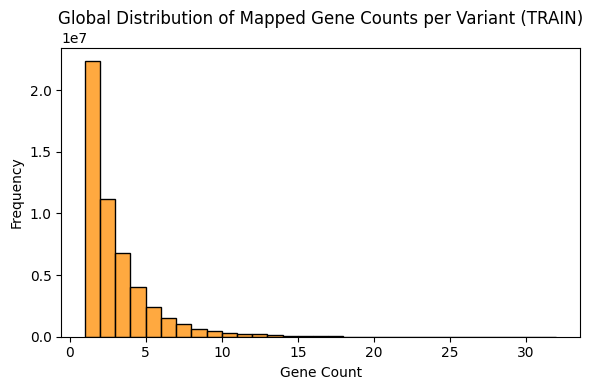

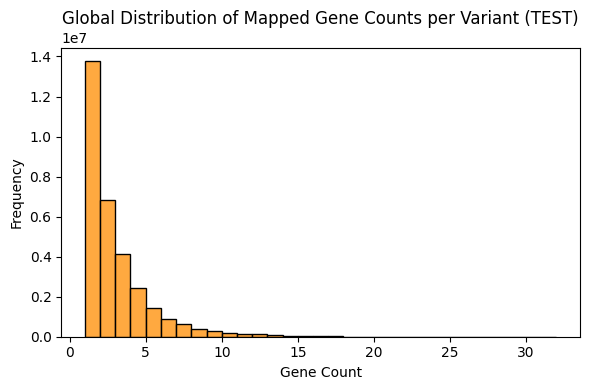

In [21]:
# Global distribution - Train
plt.figure(figsize=(6, 4))
counts = list(variants_num_genes_all_train.values())
sns.histplot(counts, bins=range(1, max(counts)+2), kde=False, color='darkorange')
plt.title('Global Distribution of Mapped Gene Counts per Variant (TRAIN)')
plt.xlabel('Gene Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Global distribution - Test
plt.figure(figsize=(6, 4))
counts = list(variants_num_genes_all_test.values())
sns.histplot(counts, bins=range(1, max(counts)+2), kde=False, color='darkorange')
plt.title('Global Distribution of Mapped Gene Counts per Variant (TEST)')
plt.xlabel('Gene Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


In [25]:
# Gene to number of variants mapping

gene_num_variants_train = defaultdict(int)
gene_num_variants_test = defaultdict(int)

for chrom in range(1,23):
    gene_stats_file_train = os.path.join(ANNOTATIONS_DIR_TRAIN, f"chr{chrom}", f"gene_variant_counts.txt")
    stats_df_train = pd.read_csv(gene_stats_file_train, sep="\t")
    for _, row in stats_df_train.iterrows():
        gene_num_variants_train[row['gene']] += row['unique_variant_count']
        
    gene_stats_file_test = os.path.join(ANNOTATIONS_DIR_TEST, f"chr{chrom}", f"gene_variant_counts.txt")
    stats_df_test = pd.read_csv(gene_stats_file_test, sep="\t")
    for _, row in stats_df_test.iterrows():
        gene_num_variants_test[row['gene']] += row['unique_variant_count']
       

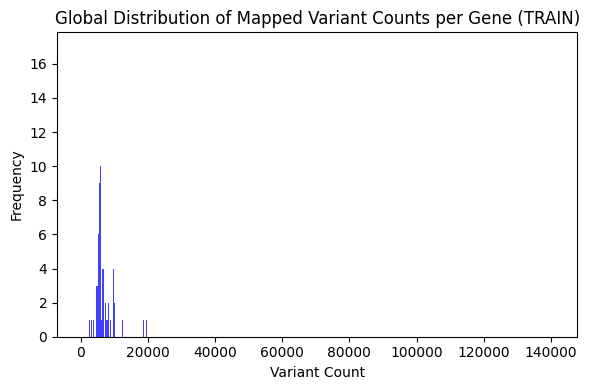

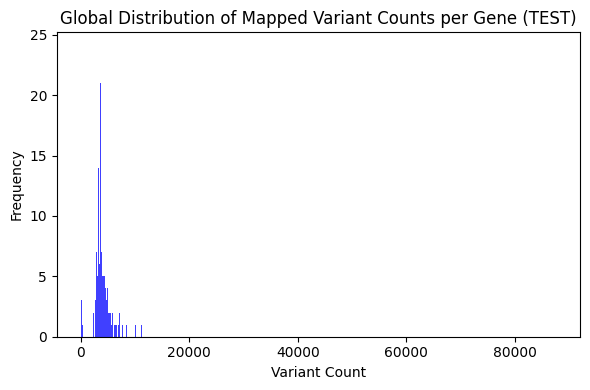

In [26]:
# Global distribution - Train
plt.figure(figsize=(6, 4))
counts = list(gene_num_variants_train.values())
sns.histplot(counts, bins=range(1, max(counts)+2), kde=False, color='blue')
plt.title('Global Distribution of Mapped Variant Counts per Gene (TRAIN)')
plt.xlabel('Variant Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Global distribution - Test
plt.figure(figsize=(6, 4))
counts = list(gene_num_variants_test.values())
sns.histplot(counts, bins=range(1, max(counts)+2), kde=False, color='blue')
plt.title('Global Distribution of Mapped Variant Counts per Gene (TEST)')
plt.xlabel('Variant Count')
plt.ylabel('Frequency') 
plt.tight_layout()
plt.show()